In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import shap
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

from src.amp_colabfold.models import (
    FEATURE_COLS, RESULTS_DIR,
    make_binary_labels, identity_split,
    train_gb_classifier, evaluate_classifier,
    compute_shap_values, shap_importance_df,
)

PROCESSED_DIR = Path("..") / "data" / "processed"

df = pd.read_csv(PROCESSED_DIR / "curated_amps_features.csv")
print(f"Loaded {len(df)} sequences")
print(f"Activity distribution:\n{df['activity'].value_counts()}")

Loaded 12435 sequences
Activity distribution:
activity
natural          5465
antibacterial    3593
general          3377
Name: count, dtype: int64


In [2]:
# binary labels: antibacterial=1, general/natural=0
y = make_binary_labels(df["activity"])
X = df[FEATURE_COLS].values

print(f"Feature matrix: {X.shape}")
print(f"Positive class (antibacterial): {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Negative class (general/natural): {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

# identity-aware split
train_idx, test_idx = identity_split(df)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print(f"\nTrain: {len(train_idx)} | Test: {len(test_idx)}")

Feature matrix: (12435, 14)
Positive class (antibacterial): 3593 (28.9%)
Negative class (general/natural): 8842 (71.1%)

Train: 9915 | Test: 2520


In [3]:
print("Training gradient boosting classifier ...")
clf = train_gb_classifier(X_train, y_train)
print("Done.")
print(f"Train score: {clf.score(X_train, y_train):.4f}")
print(f"Test score:  {clf.score(X_test, y_test):.4f}")

Training gradient boosting classifier ...
Done.
Train score: 0.9007
Test score:  0.7198


In [4]:
metrics = evaluate_classifier(clf, X_test, y_test)

print(f"ROC-AUC:           {metrics['roc_auc']:.4f}")
print(f"Avg precision:     {metrics['avg_precision']:.4f}")
print(f"\n{metrics['classification_report']}")

# save metrics
pd.DataFrame([{
    "model": "GradientBoosting_physicochemical",
    "roc_auc": metrics["roc_auc"],
    "avg_precision": metrics["avg_precision"],
}]).to_csv(RESULTS_DIR / "model_performance.csv", index=False)
print(f"Saved → {RESULTS_DIR / 'model_performance.csv'}")

ROC-AUC:           0.7678
Avg precision:     0.6892

              precision    recall  f1-score   support

    negative       0.74      0.81      0.78      1502
    positive       0.68      0.58      0.63      1018

    accuracy                           0.72      2520
   macro avg       0.71      0.70      0.70      2520
weighted avg       0.72      0.72      0.72      2520

Saved → D:\Github_projects\amp-colabfold\results\model_performance.csv


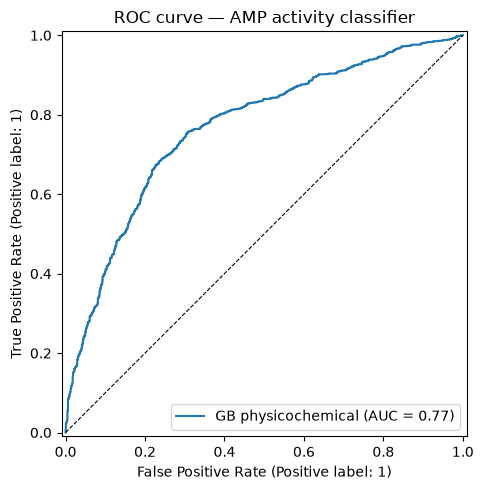

Saved → results/figures/roc_curve.png


In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, metrics["y_proba"],
    name="GB physicochemical",
    ax=ax,
)
ax.plot([0,1],[0,1],"k--", lw=0.8)
ax.set_title("ROC curve — AMP activity classifier")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "roc_curve.png", dpi=150)
plt.show()
print("Saved → results/figures/roc_curve.png")

In [6]:
print("Computing SHAP values (this takes ~30 seconds) ...")
shap_vals, explainer, X_sample = compute_shap_values(
    clf, X_train, FEATURE_COLS, sample_size=2000
)

importance_df = shap_importance_df(shap_vals, FEATURE_COLS)
print("\nTop features by mean |SHAP|:")
print(importance_df.to_string(index=False))
importance_df.to_csv(RESULTS_DIR / "shap_importance.csv", index=False)

Computing SHAP values (this takes ~30 seconds) ...

Top features by mean |SHAP|:
                 feature  mean_abs_shap
                  length       1.068294
          fraction_helix       0.482622
       fraction_positive       0.415463
       fraction_negative       0.269298
             boman_index       0.205115
hydrophobicity_eisenberg       0.176191
          fraction_sheet       0.154573
           fraction_turn       0.141688
      hydrophobic_moment       0.085613
             aromaticity       0.073661
          net_charge_pH7       0.063615
       isoelectric_point       0.060554
         aliphatic_index       0.060037
       instability_index       0.053668


In [7]:
fig = px.bar(
    importance_df,
    x="mean_abs_shap",
    y="feature",
    orientation="h",
    title="Feature importance — mean |SHAP| value",
    labels={"mean_abs_shap": "Mean |SHAP|", "feature": "Feature"},
    template="simple_white",
    color="mean_abs_shap",
    color_continuous_scale="Blues",
)
fig.update_layout(yaxis=dict(categoryorder="total ascending"), showlegend=False)
fig.write_image(str(RESULTS_DIR / "figures" / "shap_importance.png"))
fig.show()

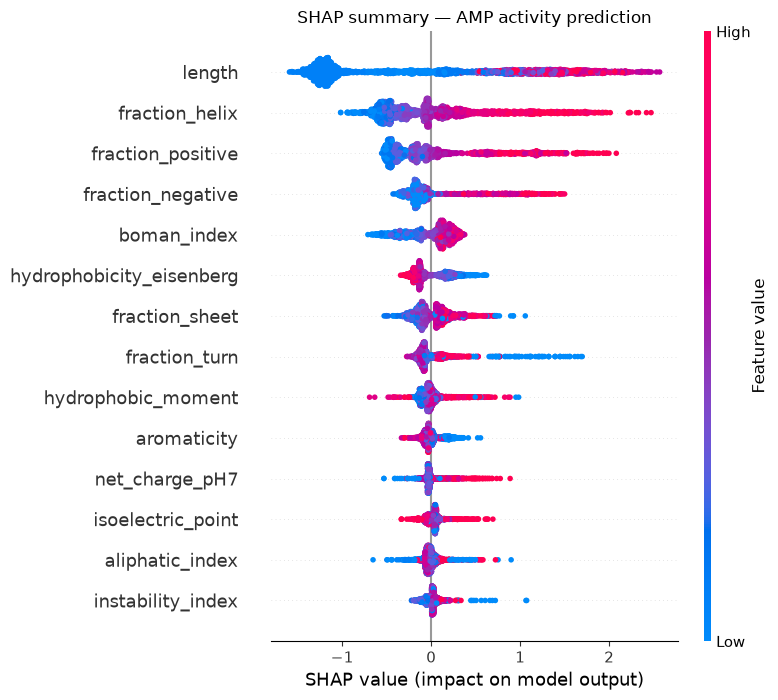

Saved → results/figures/shap_beeswarm.png


In [8]:
shap.initjs()
plt.figure()
shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=FEATURE_COLS,
    plot_type="dot",
    show=False,
    max_display=14,
)
plt.title("SHAP summary — AMP activity prediction")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/shap_beeswarm.png")

In [9]:
# Select top 200 antibacterial candidates by predicted probability
df["ab_proba"] = np.nan
df.loc[test_idx, "ab_proba"] = metrics["y_proba"]

# fill train set probabilities too
train_proba = clf.predict_proba(X_train)[:, 1]
df.loc[train_idx, "ab_proba"] = train_proba

# filter: predicted antibacterial probability > 0.7, length 10-40 aa
# (shorter peptides fold faster and are more therapeutically relevant)
candidates = (
    df[df["ab_proba"] >= 0.7]
    .sort_values("ab_proba", ascending=False)
    .head(200)
    .reset_index(drop=True)
)

print(f"Candidate peptides selected: {len(candidates)}")
print(f"Probability range: {candidates['ab_proba'].min():.3f} – {candidates['ab_proba'].max():.3f}")
print(f"Length range: {candidates['length'].min()} – {candidates['length'].max()} aa")
print(f"\nTop 10:")
candidates[["amp_id", "sequence", "length", "activity", "ab_proba"]].head(10)

Candidate peptides selected: 200
Probability range: 0.938 – 0.997
Length range: 10 – 50 aa

Top 10:


,amp_id,sequence,length,activity,ab_proba
0,AMP_10420,KKKKKKKKKKKKKKK,15,antibacterial,0.996625
1,AMP_12297,KKKKKKKKKK,10,antibacterial,0.992691
2,AMP_10422,RRRRRRRRRRRRRRR,15,antibacterial,0.992231
3,AMP_11275,RRRRRRRRRRRRR,13,antibacterial,0.991309
4,AMP_11964,RRRRRRRRRRR,11,antibacterial,0.991309
5,AMP_00188,RVVRVVRRVVRRVRRVVRRVVRVVRRVVRRVRRVVRRVVRVVRRVVRR,48,antibacterial,0.985188
6,AMP_01454,LLRAIEAQQHLLQLTVWQIKQLQARILAVERYLKDQ,36,antibacterial,0.984935
7,AMP_01820,IEKKIEAIEKKIEAIEKLLQLTVWGIKQLQARIL,34,antibacterial,0.983852
8,AMP_12292,KNKGKKNGKH,10,antibacterial,0.982726
9,AMP_01361,VRRVVRRVVRVVRRVVRRVRRVVRRVVRVVRRVVRR,36,antibacterial,0.982656


In [10]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

def is_low_complexity(seq: str, threshold: float = 0.5) -> bool:
    """
    Flag sequences where a single amino acid dominates > threshold fraction.
    Also flags tandem repeat sequences (RVV-type patterns).
    """
    seq = seq.upper()
    max_freq = max(seq.count(aa) for aa in set(seq)) / len(seq)
    if max_freq > threshold:
        return True
    # flag if any 3-mer repeats cover > 60% of the sequence
    for i in range(len(seq) - 2):
        kmer = seq[i:i+3]
        if seq.count(kmer) * 3 / len(seq) > 0.6:
            return True
    return False

# apply filter
candidates["low_complexity"] = candidates["sequence"].apply(is_low_complexity)
print(f"Low complexity sequences flagged: {candidates['low_complexity'].sum()}")

# keep only structured candidates: length 15-45 aa, not low complexity
structured = (
    candidates[
        (~candidates["low_complexity"]) &
        (candidates["length"].between(15, 45))
    ]
    .head(200)
    .reset_index(drop=True)
)

print(f"Structured candidates: {len(structured)}")
print(f"Length range: {structured['length'].min()} – {structured['length'].max()} aa")
print(f"\nTop 10 after filtering:")
structured[["amp_id", "sequence", "length", "activity", "ab_proba"]].head(10)

Low complexity sequences flagged: 44
Structured candidates: 131
Length range: 15 – 44 aa

Top 10 after filtering:


,amp_id,sequence,length,activity,ab_proba
0,AMP_01454,LLRAIEAQQHLLQLTVWQIKQLQARILAVERYLKDQ,36,antibacterial,0.984935
1,AMP_01820,IEKKIEAIEKKIEAIEKLLQLTVWGIKQLQARIL,34,antibacterial,0.983852
2,AMP_02868,IEEKIEEIEELLQLTVWGIKQLQARIL,27,antibacterial,0.981696
3,AMP_01282,NLLRAIEAQQHLLQLTVWQIKQLQARILAVERYLKDQ,37,antibacterial,0.981082
4,AMP_00741,QARQLLSGIVQQQNNLLRAIEAQQHLLQLTVWGIKQLQARIL,42,antibacterial,0.979451
5,AMP_01647,LRAIEAQQHLLQLTVWQIKQLQARILAVERYLKDQ,35,antibacterial,0.977416
6,AMP_01818,IKKEIEAIKKEQEAIKKLLQLTVWGIKQLQARIL,34,antibacterial,0.976644
7,AMP_01646,NNLLRAIEAQQHLLQLTVWQIKQLQARILAVERYL,35,antibacterial,0.975897
8,AMP_01479,ATHQETIEKVTEALKINNLRLVTLEHQVLVIGLKVE,36,antibacterial,0.975479
9,AMP_02105,IEAQQHLLQLTVWQIKQLQARILAVERYLKDQ,32,antibacterial,0.975442


In [11]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from pathlib import Path

# save structured candidates metadata
structured.to_csv(
    Path("..") / "data" / "processed" / "colabfold_candidates.csv",
    index=False
)

# save FASTA for ColabFold input
fasta_path = Path("..") / "data" / "processed" / "colabfold_input.fasta"
records = [
    SeqRecord(
        Seq(row.sequence),
        id=row.amp_id,
        description=f"length={row.length} ab_proba={row.ab_proba:.4f}",
    )
    for row in structured.itertuples()
]
SeqIO.write(records, fasta_path, "fasta")

print(f"Saved {len(records)} sequences → {fasta_path}")
print("\nFirst 3 FASTA entries:")
for rec in records[:3]:
    print(f">{rec.id} {rec.description}")
    print(f"{rec.seq}\n")

Saved 131 sequences → ..\data\processed\colabfold_input.fasta

First 3 FASTA entries:
>AMP_01454 length=36 ab_proba=0.9849
LLRAIEAQQHLLQLTVWQIKQLQARILAVERYLKDQ

>AMP_01820 length=34 ab_proba=0.9839
IEKKIEAIEKKIEAIEKLLQLTVWGIKQLQARIL

>AMP_02868 length=27 ab_proba=0.9817
IEEKIEEIEELLQLTVWGIKQLQARIL

